# South Africa Public Procument Analysis

**1. Setup - Import Libriries & Load cleaned data**

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker 
import seaborn as sns 
import warnings 
warnings.filterwarnings("ignore")

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Blues_d')

plt.rcParams["figure.dpi"] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'

# Load cleaned datasets
main       = pd.read_csv("../01_cleaned_data/main_clean_cleaned.csv", low_memory=False)
awards     = pd.read_csv("../01_cleaned_data/awards_clean_cleaned.csv")
contracts  = pd.read_csv("../01_cleaned_data/contracts_clean_cleaned.csv")
parties    = pd.read_csv("../01_cleaned_data/parties_clean_cleaned.csv")
suppliers  = pd.read_csv("../01_cleaned_data/awards_suppliers_clean_cleaned.csv")
tenderers  = pd.read_csv("../01_cleaned_data/tender_tenderers_clean_cleaned.csv")


**2. Seasonal Analysis**: 
*Tenders and Value by Month and Quarter*

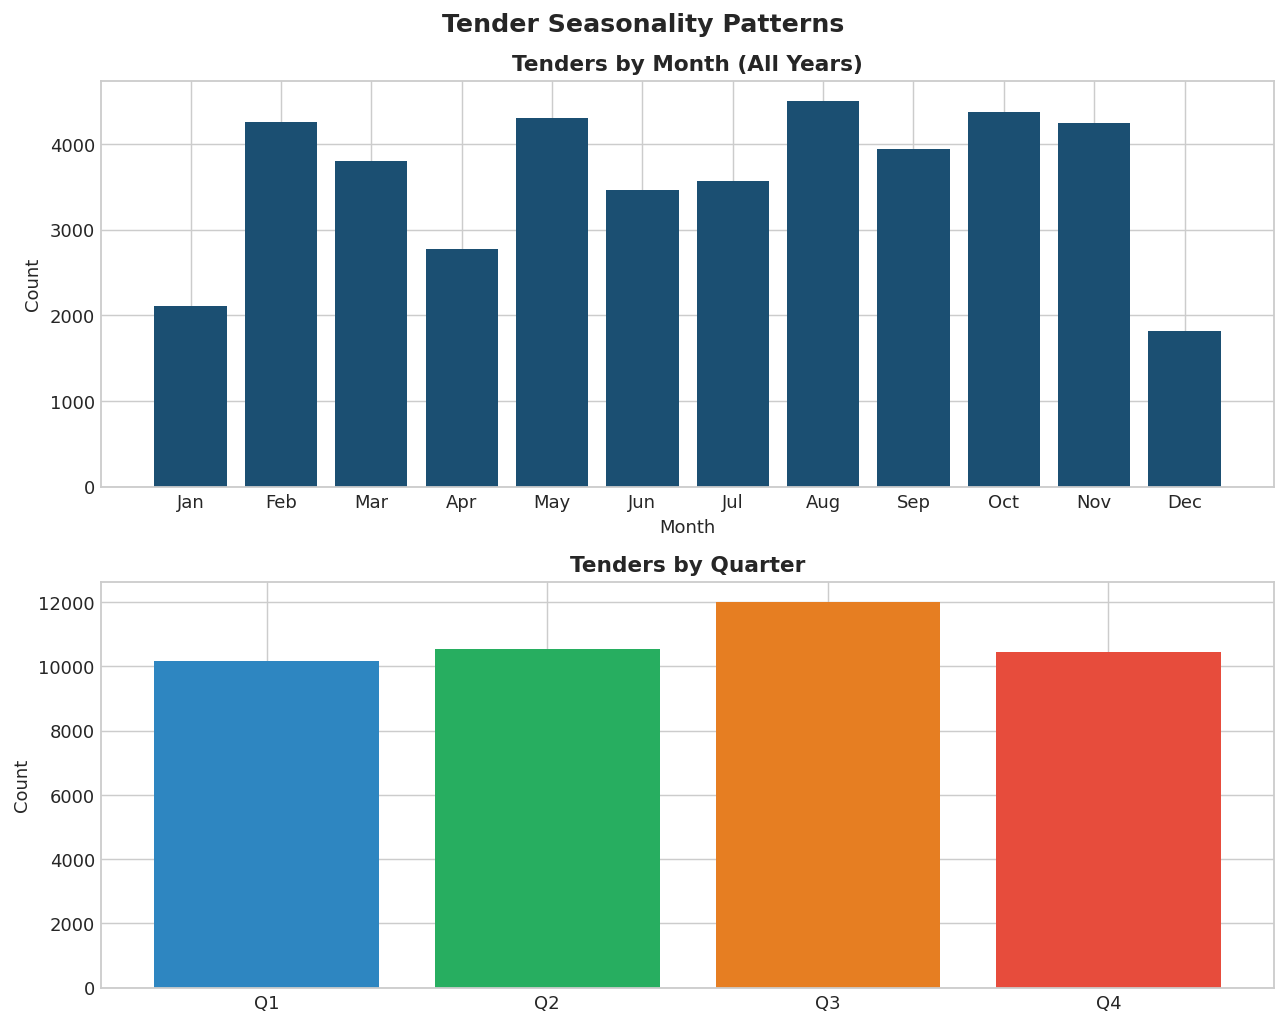

In [12]:
# Convert date columns
main['date'] = pd.to_datetime(main['date'], utc=True, errors='coerce')
main['year'] = main['date'].dt.year
main['month'] = main['date'].dt.month
main['quarter'] = main['date'].dt.quarter

contracts['datesigned'] = pd.to_datetime(contracts['datesigned'], utc=True, errors='coerce')
contracts['period_startdate'] = pd.to_datetime(contracts['period_startdate'], utc=True, errors='coerce')

# Create fig and 2 subplots
fih, axes = plt.subplots(2, 1, figsize=(10, 8))

# Monthly distribution
monthly = main.groupby('month').size()
axes[0].bar(monthly.index, monthly.values, color='#1B4F72')
axes[0].set_title('Tenders by Month (All Years)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Count')
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                        'Jul','Aug','Sep','Oct','Nov','Dec'])

# Quarterly distribution
quarterly = main.groupby('quarter').size()
colors = ['#2E86C1','#27AE60','#E67E22','#E74C3C']
axes[1].bar(['Q1','Q2','Q3','Q4'], quarterly.values, color=colors)
axes[1].set_title('Tenders by Quarter', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')

plt.suptitle("Tender Seasonality Patterns", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig('../06_outputs/02_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()


*WHY: Seasonality is a critical feature for the forecasting model. If Q3 consistently shows higher construction awards (as hypothesized), we can build that into the recommendation engine.*

**3. Provincial Analysis**: 
*Tenders and Value by Province*

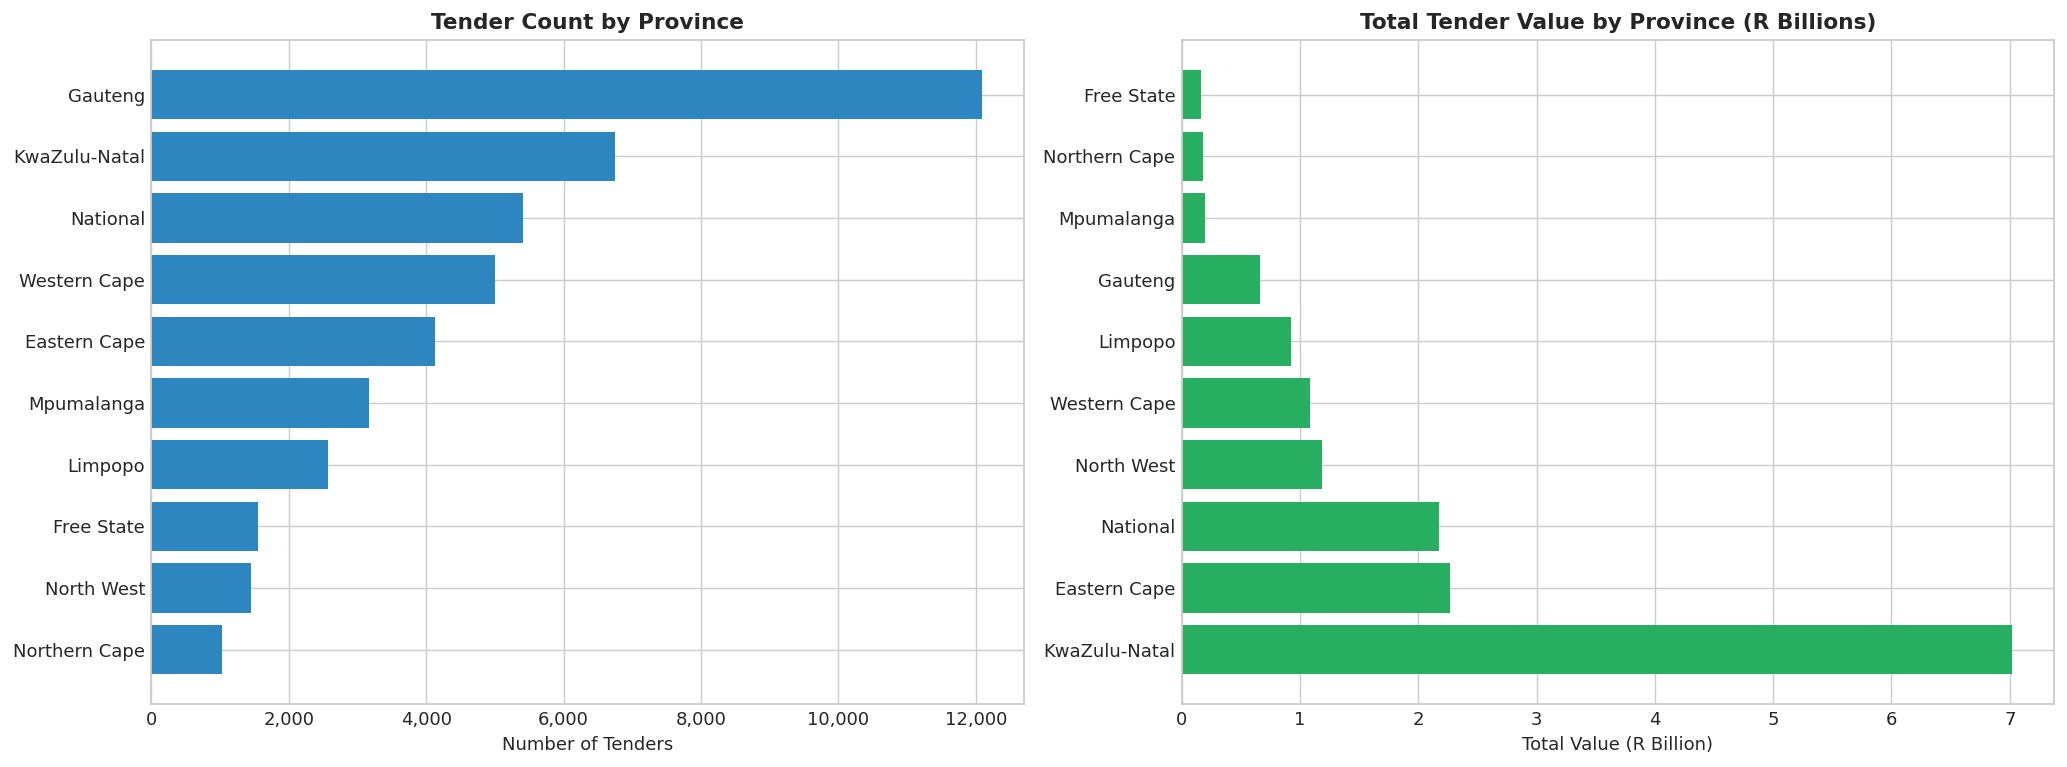

In [16]:
# Provincial Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Tender count by province
prov_count = main.groupby('tender_province').size().sort_values(ascending=True)
axes[0].barh(prov_count.index, prov_count.values, color='#2E86C1')
axes[0].set_title('Tender Count by Province', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Tenders')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

main_valued = main[['id', 'tender_province']].merge(
    contracts[['main_id', 'value_amount']],
    left_on='id',
    right_on='main_id',
    how='inner'
)

# Total value by province (exclude zeros)
prov_value = main_valued.groupby('tender_province')['value_amount'].sum().sort_values(ascending=True)
axes[1].barh(prov_value.index, prov_value.values / 1e9, color='#27AE60')
axes[1].set_title('Total Tender Value by Province (R Billions)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total Value (R Billion)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../06_outputs/04_category_analysis.png', dpi=150, bbox_inches='tight')
plt.show()



*WHY: Categories reveal the dominant procurement sectors. Construction and IT services typically account for the highest values. This directly feeds the "high-opportunity sector" intelligence output.*

**3. Award Value Analysis**: 
*Award Value by Distribution*

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram (log-transformed)
axes[0].hist(np.log1p(awards_valued['value_amount']), bins=50, color='#2E86C1', edgecolor='white')
axes[0].set_title('Log Distribution of Award Values', fontsize=11, fontweight='bold')
axes[0].set_xlabel('log(Award Value + 1)')
axes[0].set_ylabel('Frequency')

# Box plot by category (top 8)
top_cats = main_valued.groupby('tender_category')['tender_value_amount'].count().nlargest(8).index
cat_main = main_valued[main_valued['tender_category'].isin(top_cats)]
merged = awards_valued.merge(main[['ocid','tender_category']], left_on='main_ocid', right_on='ocid', how='left')
merged_top = merged[merged['tender_category'].isin(top_cats)]
merged_top.boxplot(column='value_amount', by='tender_category', ax=axes[1], rot=45)
axes[1].set_title('Award Value by Category', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Award Value (R)')
plt.sca(axes[1])
plt.xticks(fontsize=8)

# Descriptive stats
stats = awards_valued['value_amount'].describe(percentiles=[.25,.5,.75,.9,.95,.99])
axes[2].axis('off')
stat_text = '\n'.join([f'{k}: R{v:,.0f}' for k,v in stats.items()])
axes[2].text(0.1, 0.9, 'Award Value Statistics\n\n' + stat_text,
            transform=axes[2].transAxes, fontsize=10,
            verticalalignment='top', fontfamily='monospace')

plt.suptitle("Award Value Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig('../03_outputs/05_award_distribution.png', dpi=150, bbox_inches='tight')


